# Check Empty Experience Years in Jobs Data

This notebook analyzes how many job records have missing/empty experience year data.

**Fields checked:**
- `experience_years_min`
- `experience_years_max`

## 1. Install Required Libraries

In [1]:
!pip install pymysql sqlalchemy pandas matplotlib seaborn cryptography

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.9 MB/s eta 0:00:00


## 2. Import Libraries

In [2]:
import pymysql
import pandas as pd
import ssl
import tempfile
import os
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Import OK')

✅ Import OK


## 3. Database Configuration

**IMPORTANT:** Update with your database credentials and SSL certificate

In [3]:
# ========== DATABASE CONFIGURATION ==========
DB_CONFIG = {
    'host': 'gateway01.ap-southeast-1.prod.aws.tidbcloud.com',
    'port': 4000,
    'user': '4GJhpnEevqoZfyD.root',
    'password': 'oiK2dgnVVJLVHL4v',
    'database': 'data-mining',
    'charset': 'utf8mb4'
}

# ========== SSL CERTIFICATE ==========
CA_CERT_CONTENT = """
-----BEGIN CERTIFICATE-----
MIIFazCCA1OgAwIBAgIRAIIQz7DSQONZRGPgu2OCiwAwDQYJKoZIhvcNAQELBQAw
TzELMAkGA1UEBhMCVVMxKTAnBgNVBAoTIEludGVybmV0IFNlY3VyaXR5IFJlc2Vh
cmNoIEdyb3VwMRUwEwYDVQQDEwxJU1JHIFJvb3QgWDEwHhcNMTUwNjA0MTEwNDM4
WhcNMzUwNjA0MTEwNDM4WjBPMQswCQYDVQQGEwJVUzEpMCcGA1UEChMgSW50ZXJu
ZXQgU2VjdXJpdHkgUmVzZWFyY2ggR3JvdXAxFTATBgNVBAMTDElTUkcgUm9vdCBY
MTCCAiIwDQYJKoZIhvcNAQEBBQADggIPADCCAgoCggIBAK3oJHP0FDfzm54rVygc
h77ct984kIxuPOZXoHj3dcKi/vVqbvYATyjb3miGbESTtrFj/RQSa78f0uoxmyF+
0TM8ukj13Xnfs7j/EvEhmkvBioZxaUpmZmyPfjxwv60pIgbz5MDmgK7iS4+3mX6U
A5/TR5d8mUgjU+g4rk8Kb4Mu0UlXjIB0ttov0DiNewNwIRt18jA8+o+u3dpjq+sW
T8KOEUt+zwvo/7V3LvSye0rgTBIlDHCNAymg4VMk7BPZ7hm/ELNKjD+Jo2FR3qyH
B5T0Y3HsLuJvW5iB4YlcNHlsdu87kGJ55tukmi8mxdAQ4Q7e2RCOFvu396j3x+UC
B5iPNgiV5+I3lg02dZ77DnKxHZu8A/lJBdiB3QW0KtZB6awBdpUKD9jf1b0SHzUv
KBds0pjBqAlkd25HN7rOrFleaJ1/ctaJxQZBKT5ZPt0m9STJEadao0xAH0ahmbWn
OlFuhjuefXKnEgV4We0+UXgVCwOPjdAvBbI+e0ocS3MFEvzG6uBQE3xDk3SzynTn
jh8BCNAw1FtxNrQHusEwMFxIt4I7mKZ9YIqioymCzLq9gwQbooMDQaHWBfEbwrbw
qHyGO0aoSCqI3Haadr8faqU9GY/rOPNk3sgrDQoo//fb4hVC1CLQJ13hef4Y53CI
rU7m2Ys6xt0nUW7/vGT1M0NPAgMBAAGjQjBAMA4GA1UdDwEB/wQEAwIBBjAPBgNV
HRMBAf8EBTADAQH/MB0GA1UdDgQWBBR5tFnme7bl5AFzgAiIyBpY9umbbjANBgkq
hkiG9w0BAQsFAAOCAgEAVR9YqbyyqFDQDLHYGmkgJykIrGF1XIpu+ILlaS/V9lZL
ubhzEFnTIZd+50xx+7LSYK05qAvqFyFWhfFQDlnrzuBZ6brJFe+GnY+EgPbk6ZGQ
3BebYhtF8GaV0nxvwuo77x/Py9auJ/GpsMiu/X1+mvoiBOv/2X/qkSsisRcOj/KK
NFtY2PwByVS5uCbMiogziUwthDyC3+6WVwW6LLv3xLfHTjuCvjHIInNzktHCgKQ5
ORAzI4JMPJ+GslWYHb4phowim57iaztXOoJwTdwJx4nLCgdNbOhdjsnvzqvHu7Ur
TkXWStAmzOVyyghqpZXjFaH3pO3JLF+l+/+sKAIuvtd7u+Nxe5AW0wdeRlN8NwdC
jNPElpzVmbUq4JUagEiuTDkHzsxHpFKVK7q4+63SM1N95R1NbdWhscdCb+ZAJzVc
oyi3B43njTOQ5yOf+1CceWxG1bQVs5ZufpsMljq4Ui0/1lvh+wjChP4kqKOJ2qxq
4RgqsahDYVvTH9w7jXbyLeiNdd8XM2w9U/t7y0Ff/9yi0GE44Za4rF2LN9d11TPA
mRGunUHBcnWEvgJBQl9nJEiU0Zsnvgc/ubhPgXRR4Xq37Z0j4r7g1SgEEzwxA57d
emyPxgcYxn/eR44/KJ4EBs+lVDR3veyJm+kXQ99b21/+jh5Xos1AnX5iItreGCc=
-----END CERTIFICATE-----
""".strip()

CLIENT_CERT_CONTENT = None
CLIENT_KEY_CONTENT = None

print(f'📊 Database: {DB_CONFIG["database"]}')
print(f'🔗 Host: {DB_CONFIG["host"]}:{DB_CONFIG["port"]}')
print(f'📜 CA Cert: {"✅" if len(CA_CERT_CONTENT) > 100 else "❌ Not configured"}')

📊 Database: data-mining
🔗 Host: gateway01.ap-southeast-1.prod.aws.tidbcloud.com:4000
📜 CA Cert: ✅


## 4. Create SSL Connection

In [4]:
temp_files = []
try:
    ssl_context = ssl.create_default_context()
    
    if CA_CERT_CONTENT:
        ca_temp = tempfile.NamedTemporaryFile(mode='w', suffix='.pem', delete=False)
        ca_temp.write(CA_CERT_CONTENT)
        ca_temp.close()
        temp_files.append(ca_temp.name)
        ssl_context.load_verify_locations(ca_temp.name)
        print('✅ Loaded CA certificate')
    
    if CLIENT_CERT_CONTENT and CLIENT_KEY_CONTENT:
        cert_temp = tempfile.NamedTemporaryFile(mode='w', suffix='.pem', delete=False)
        cert_temp.write(CLIENT_CERT_CONTENT)
        cert_temp.close()
        key_temp = tempfile.NamedTemporaryFile(mode='w', suffix='.pem', delete=False)
        key_temp.write(CLIENT_KEY_CONTENT)
        key_temp.close()
        temp_files.extend([cert_temp.name, key_temp.name])
        ssl_context.load_cert_chain(cert_temp.name, key_temp.name)
        print('✅ Loaded client certificate')
    
    DATABASE_URL = f"mysql+pymysql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}?charset={DB_CONFIG['charset']}"
    engine = create_engine(DATABASE_URL, connect_args={'ssl': ssl_context}, pool_pre_ping=True)
    
    print('\n🔄 Testing connection...')
    with engine.connect() as conn:
        result = conn.execute(text('SELECT COUNT(*) FROM jobs'))
        total = result.fetchone()[0]
        print(f'\n✅ Connection successful!')
        print(f'📊 Total jobs: {total:,}')
        
except Exception as e:
    print(f'❌ Error: {e}')
    for f in temp_files:
        try: os.unlink(f)
        except: pass
    raise

✅ Loaded CA certificate

🔄 Testing connection...

✅ Connection successful!
📊 Total jobs: 12,117


## 5. Analyze Empty Experience Years

In [5]:
print('🔍 Analyzing experience years data...\n')
print('='*100)

# Query to check empty experience years
query = '''
SELECT 
    COUNT(*) as total_jobs,
    SUM(CASE WHEN experience_years_min IS NULL THEN 1 ELSE 0 END) as empty_min,
    SUM(CASE WHEN experience_years_max IS NULL THEN 1 ELSE 0 END) as empty_max,
    SUM(CASE WHEN experience_years_min IS NULL AND experience_years_max IS NULL THEN 1 ELSE 0 END) as empty_both,
    SUM(CASE WHEN experience_years_min IS NOT NULL OR experience_years_max IS NOT NULL THEN 1 ELSE 0 END) as has_data,
    SUM(CASE WHEN experience_years_min IS NOT NULL AND experience_years_max IS NOT NULL THEN 1 ELSE 0 END) as has_both
FROM jobs
'''

stats = pd.read_sql(query, engine)

total = stats['total_jobs'].iloc[0]
empty_min = stats['empty_min'].iloc[0]
empty_max = stats['empty_max'].iloc[0]
empty_both = stats['empty_both'].iloc[0]
has_data = stats['has_data'].iloc[0]
has_both = stats['has_both'].iloc[0]

print(f'📊 TOTAL JOBS: {total:,}')
print('='*100)
print(f'\n❌ MISSING DATA:')
print(f'   experience_years_min is NULL: {empty_min:,} ({empty_min/total*100:.2f}%)')
print(f'   experience_years_max is NULL: {empty_max:,} ({empty_max/total*100:.2f}%)')
print(f'   BOTH fields are NULL: {empty_both:,} ({empty_both/total*100:.2f}%)')
print(f'\n✅ HAS DATA:')
print(f'   At least one field has data: {has_data:,} ({has_data/total*100:.2f}%)')
print(f'   BOTH fields have data: {has_both:,} ({has_both/total*100:.2f}%)')
print('='*100)

🔍 Analyzing experience years data...

📊 TOTAL JOBS: 12,117

❌ MISSING DATA:
   experience_years_min is NULL: 392.0 (3.24%)
   experience_years_max is NULL: 392.0 (3.24%)
   BOTH fields are NULL: 392.0 (3.24%)

✅ HAS DATA:
   At least one field has data: 11,725.0 (96.76%)
   BOTH fields have data: 11,725.0 (96.76%)


## 6. Breakdown by Source

In [6]:
query_by_source = '''
SELECT 
    source,
    COUNT(*) as total_jobs,
    SUM(CASE WHEN experience_years_min IS NULL AND experience_years_max IS NULL THEN 1 ELSE 0 END) as empty_both,
    SUM(CASE WHEN experience_years_min IS NOT NULL OR experience_years_max IS NOT NULL THEN 1 ELSE 0 END) as has_data,
    SUM(CASE WHEN experience_years_min IS NOT NULL AND experience_years_max IS NOT NULL THEN 1 ELSE 0 END) as has_both
FROM jobs
GROUP BY source
ORDER BY total_jobs DESC
'''

by_source = pd.read_sql(query_by_source, engine)
by_source['empty_both_pct'] = (by_source['empty_both'] / by_source['total_jobs'] * 100).round(2)
by_source['has_data_pct'] = (by_source['has_data'] / by_source['total_jobs'] * 100).round(2)
by_source['has_both_pct'] = (by_source['has_both'] / by_source['total_jobs'] * 100).round(2)

print('\n📊 BREAKDOWN BY SOURCE:')
print('='*100)
print(by_source.to_string(index=False))
print('='*100)


📊 BREAKDOWN BY SOURCE:
  source  total_jobs  empty_both  has_data  has_both  empty_both_pct  has_data_pct  has_both_pct
linkedin        9132       368.0    8764.0    8764.0            4.03         95.97         95.97
   topcv        1941         1.0    1940.0    1940.0            0.05         99.95         99.95
  itviec         743         8.0     735.0     735.0            1.08         98.92         98.92
  topdev         301        15.0     286.0     286.0            4.98         95.02         95.02


## 7. Visualize Data Completeness


✅ Chart saved as: experience_years_analysis.png


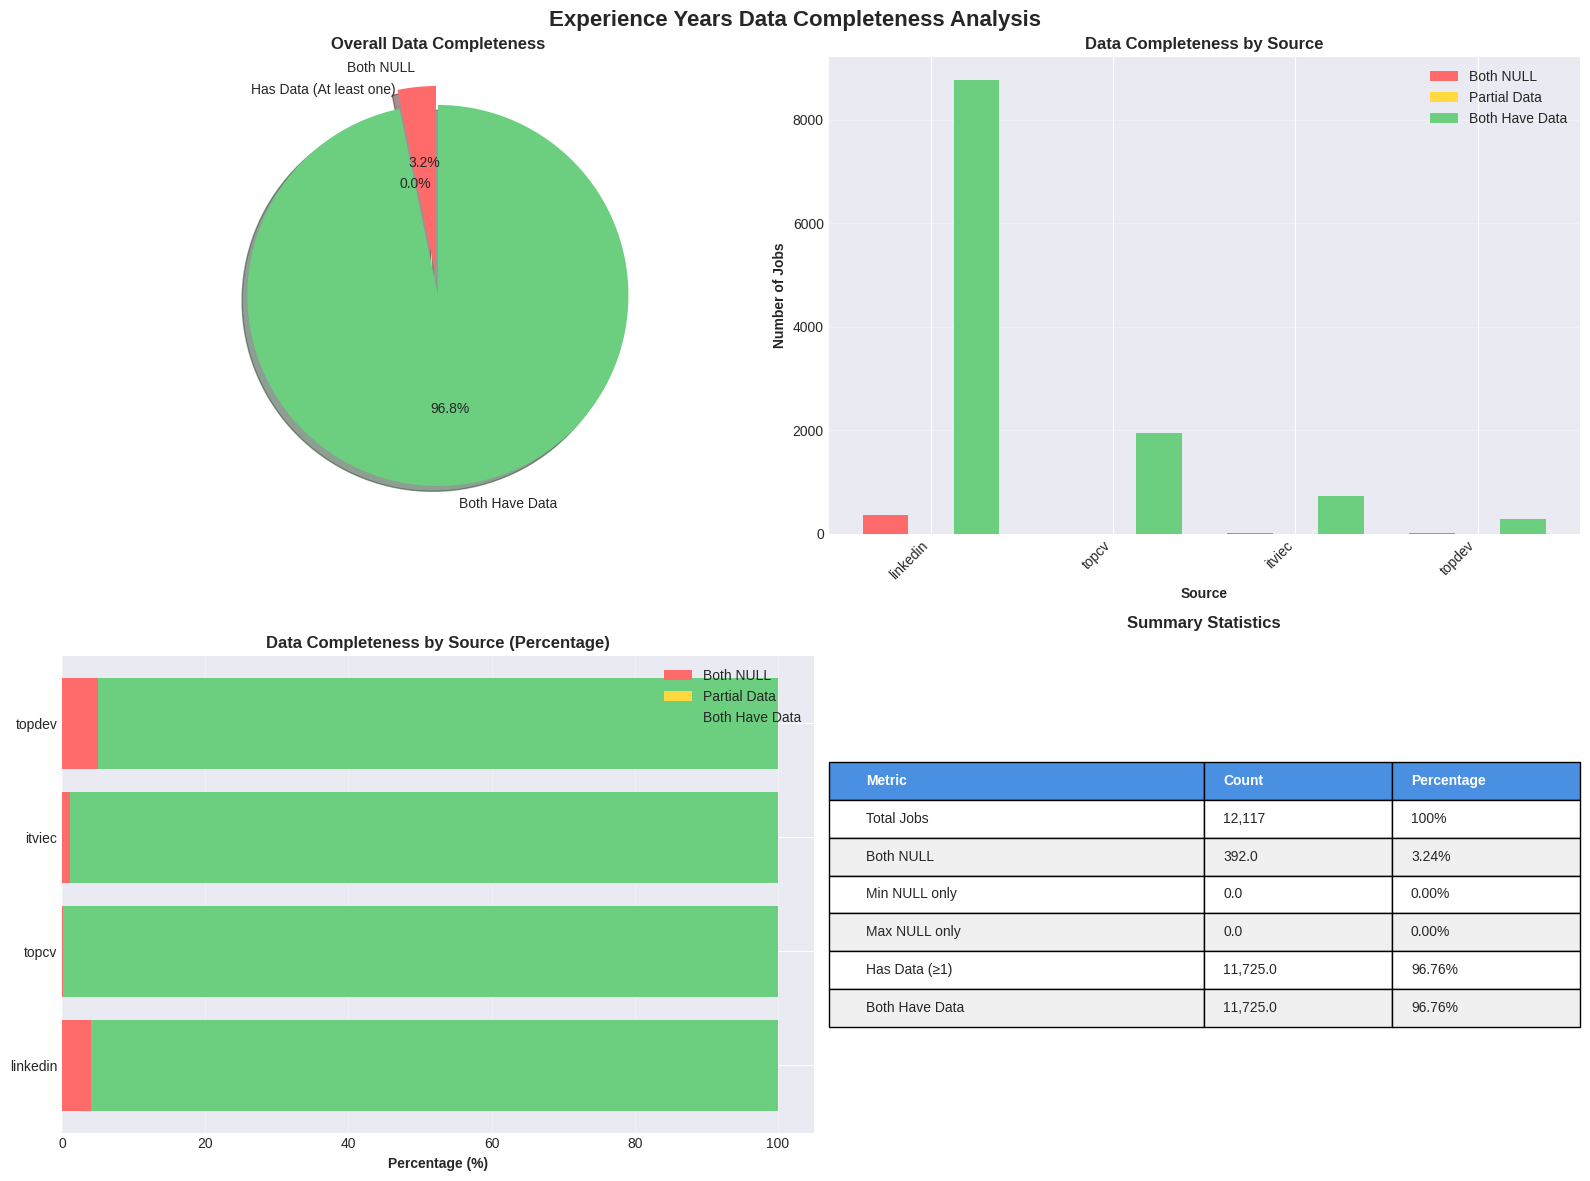

In [7]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Experience Years Data Completeness Analysis', fontsize=16, fontweight='bold')

# 1. Overall completeness pie chart
ax1 = axes[0, 0]
labels = ['Both NULL', 'Has Data (At least one)', 'Both Have Data']
sizes = [empty_both, has_data - has_both, has_both]
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f']
explode = (0.1, 0, 0)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.set_title('Overall Data Completeness', fontweight='bold')

# 2. Bar chart by source
ax2 = axes[0, 1]
x = range(len(by_source))
width = 0.25

ax2.bar([i - width for i in x], by_source['empty_both'], width, label='Both NULL', color='#ff6b6b')
ax2.bar(x, by_source['has_data'] - by_source['has_both'], width, label='Partial Data', color='#ffd93d')
ax2.bar([i + width for i in x], by_source['has_both'], width, label='Both Have Data', color='#6bcf7f')

ax2.set_xlabel('Source', fontweight='bold')
ax2.set_ylabel('Number of Jobs', fontweight='bold')
ax2.set_title('Data Completeness by Source', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(by_source['source'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Percentage stacked bar chart
ax3 = axes[1, 0]
sources = by_source['source']
empty_pct = by_source['empty_both_pct']
partial_pct = by_source['has_data_pct'] - by_source['has_both_pct']
both_pct = by_source['has_both_pct']

ax3.barh(sources, empty_pct, label='Both NULL', color='#ff6b6b')
ax3.barh(sources, partial_pct, left=empty_pct, label='Partial Data', color='#ffd93d')
ax3.barh(sources, both_pct, left=empty_pct + partial_pct, label='Both Have Data', color='#6bcf7f')

ax3.set_xlabel('Percentage (%)', fontweight='bold')
ax3.set_title('Data Completeness by Source (Percentage)', fontweight='bold')
ax3.legend()
ax3.grid(axis='x', alpha=0.3)

# 4. Summary statistics table
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

summary_data = [
    ['Metric', 'Count', 'Percentage'],
    ['Total Jobs', f'{total:,}', '100%'],
    ['Both NULL', f'{empty_both:,}', f'{empty_both/total*100:.2f}%'],
    ['Min NULL only', f'{empty_min - empty_both:,}', f'{(empty_min - empty_both)/total*100:.2f}%'],
    ['Max NULL only', f'{empty_max - empty_both:,}', f'{(empty_max - empty_both)/total*100:.2f}%'],
    ['Has Data (≥1)', f'{has_data:,}', f'{has_data/total*100:.2f}%'],
    ['Both Have Data', f'{has_both:,}', f'{has_both/total*100:.2f}%']
]

table = ax4.table(cellText=summary_data, cellLoc='left', loc='center',
                  colWidths=[0.5, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(3):
    table[(0, i)].set_facecolor('#4a90e2')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data)):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

ax4.set_title('Summary Statistics', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('experience_years_analysis.png', dpi=300, bbox_inches='tight')
print('\n✅ Chart saved as: experience_years_analysis.png')
plt.show()

## 8. Sample Jobs with Missing Data

In [8]:
# Get sample of jobs with missing experience years
query_sample = '''
SELECT id, title, company_name, location, source, experience_years_min, experience_years_max
FROM jobs
WHERE experience_years_min IS NULL AND experience_years_max IS NULL
LIMIT 10
'''

sample_empty = pd.read_sql(query_sample, engine)

print('\n📋 SAMPLE JOBS WITH MISSING EXPERIENCE YEARS (Both NULL):')
print('='*100)
print(sample_empty.to_string(index=False))
print('='*100)


📋 SAMPLE JOBS WITH MISSING EXPERIENCE YEARS (Both NULL):
  id                                                                                              title          company_name                         location source experience_years_min experience_years_max
3465                                                       Publishing staff - Webtoon/Manga - Full-time DaouKiwoom Innovation District Bình Thạnh, Hồ Chí Minh topdev                 None                 None
3466                                                            Webtoon Colorist - Colorist - Full-time DaouKiwoom Innovation District Bình Thạnh, Hồ Chí Minh topdev                 None                 None
3468                                         Data Engineer - Information Technology Division (HO25.504)                MBBANK        District Cầu Giấy, Hà Nội topdev                 None                 None
3480                   FullStack Developer (Junior, Senior) - Information Technology Division (HOLT.04)       

## 9. Distribution of Experience Years (for jobs with data)


✅ Chart saved as: experience_years_distribution.png


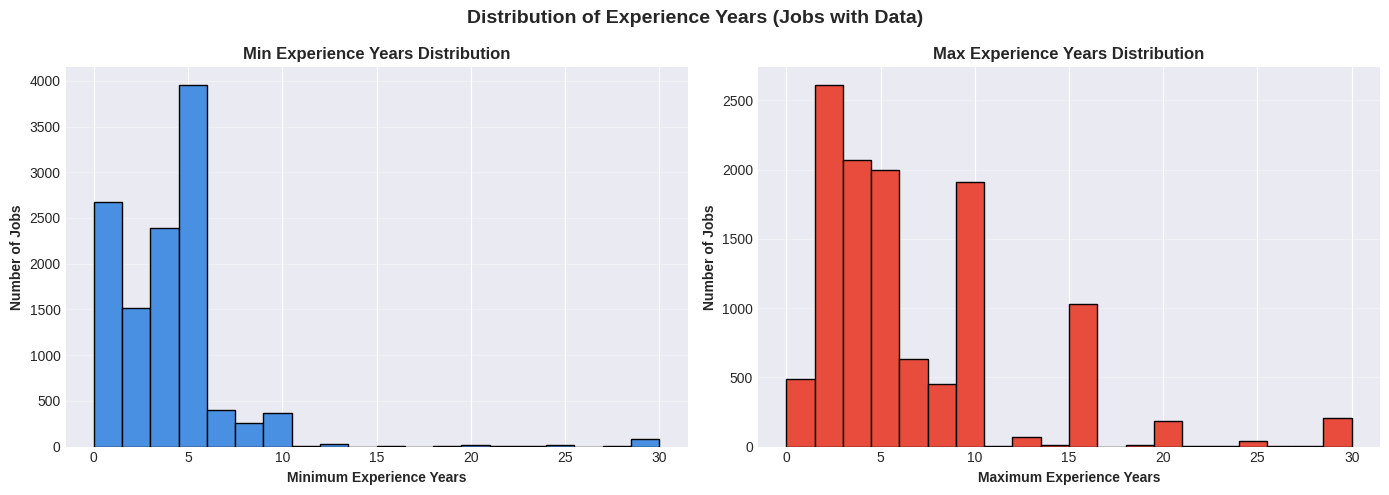


📊 EXPERIENCE YEARS STATISTICS:

Minimum Experience Years:
count    11725.000000
mean         3.730320
std          3.463723
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         30.000000
Name: experience_years_min, dtype: float64

Maximum Experience Years:
count    11725.000000
mean         6.581151
std          5.560084
min          0.000000
25%          2.000000
50%          5.000000
75%         10.000000
max         30.000000
Name: experience_years_max, dtype: float64


In [9]:
# Get jobs with experience years data
query_exp_dist = '''
SELECT experience_years_min, experience_years_max
FROM jobs
WHERE experience_years_min IS NOT NULL OR experience_years_max IS NOT NULL
'''

exp_data = pd.read_sql(query_exp_dist, engine)

# Create distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Experience Years (Jobs with Data)', fontsize=14, fontweight='bold')

# Min years distribution
ax1 = axes[0]
exp_data['experience_years_min'].dropna().hist(bins=20, ax=ax1, color='#4a90e2', edgecolor='black')
ax1.set_xlabel('Minimum Experience Years', fontweight='bold')
ax1.set_ylabel('Number of Jobs', fontweight='bold')
ax1.set_title('Min Experience Years Distribution', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Max years distribution
ax2 = axes[1]
exp_data['experience_years_max'].dropna().hist(bins=20, ax=ax2, color='#e74c3c', edgecolor='black')
ax2.set_xlabel('Maximum Experience Years', fontweight='bold')
ax2.set_ylabel('Number of Jobs', fontweight='bold')
ax2.set_title('Max Experience Years Distribution', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('experience_years_distribution.png', dpi=300, bbox_inches='tight')
print('\n✅ Chart saved as: experience_years_distribution.png')
plt.show()

# Show statistics
print('\n📊 EXPERIENCE YEARS STATISTICS:')
print('='*100)
print('\nMinimum Experience Years:')
print(exp_data['experience_years_min'].describe())
print('\nMaximum Experience Years:')
print(exp_data['experience_years_max'].describe())
print('='*100)

## 10. Cleanup

In [10]:
# Cleanup temporary SSL certificate files
for f in temp_files:
    try:
        os.unlink(f)
        print(f'🗑️  Deleted temp file: {f}')
    except:
        pass

print('\n' + '='*100)
print('🎉 ANALYSIS COMPLETE')
print('='*100)
print(f'\n📊 KEY FINDINGS:')
print(f'  • Total jobs analyzed: {total:,}')
print(f'  • Jobs with both fields NULL: {empty_both:,} ({empty_both/total*100:.2f}%)')
print(f'  • Jobs with at least some data: {has_data:,} ({has_data/total*100:.2f}%)')
print(f'  • Jobs with complete data (both fields): {has_both:,} ({has_both/total*100:.2f}%)')
print('\n📁 Output files:')
print('  • experience_years_analysis.png')
print('  • experience_years_distribution.png')
print('='*100)

🗑️  Deleted temp file: /tmp/tmpizj40n8f.pem

🎉 ANALYSIS COMPLETE

📊 KEY FINDINGS:
  • Total jobs analyzed: 12,117
  • Jobs with both fields NULL: 392.0 (3.24%)
  • Jobs with at least some data: 11,725.0 (96.76%)
  • Jobs with complete data (both fields): 11,725.0 (96.76%)

📁 Output files:
  • experience_years_analysis.png
  • experience_years_distribution.png
